# Weakly Supervised 3D Disease Localization — MacBook Pro M5 (Yerel)

BB annotasyonları + TotalSegmentator → **3D hastalık maskesi** (pseudo-label yok)

| Adım | İçerik |
|------|--------|
| 1 | Kontrol (MPS, paketler, dizinler) |
| 2 | Kullanıcı ayarları |
| 3 | Ortam değişkenleri |
| **4** | **Maske üretimi** (`generate_weak_masks`) |
| 5 | İstatistikler |
| 6 | CT + Maske görselleştirme |
| 7 | Analiz: BB Coverage & Z-range |


## [1] Kontrol — MPS, Paketler, Dizinler

In [5]:
import sys
from pathlib import Path

# Proje kökünü sys.path'e ekle
PROJECT = Path('abdomen_project').resolve()
if str(PROJECT) not in sys.path:
    sys.path.insert(0, str(PROJECT))

# MPS / PyTorch kontrolü
import torch
mps_ok = torch.backends.mps.is_available()
print(f'PyTorch  : {torch.__version__}')
print(f'MPS      : {"OK (Apple Silicon GPU)" if mps_ok else "YOK"}')

# Paket kontrolleri
import SimpleITK as sitk, pydicom, pandas, numpy
print(f'SimpleITK: {sitk.Version()}')
print(f'pydicom  : {pydicom.__version__}')
print(f'pandas   : {pandas.__version__}')

# TotalSegmentator Python API kontrolü (CLI değil)
from totalsegmentator.python_api import totalsegmentator as _ts_api
print('TotalSegmentator Python API: OK')

# Dizin kontrolleri
BASE = Path('.')
checks = {
    'Bilgi.xlsx'                          : BASE / 'Bilgi.xlsx',
    'Test Verisi/'                  : BASE / 'Test Verisi',
    'src/weak_seg.py'     : BASE / 'src' / 'weak_seg.py',
    'outputs/splits/manifest.csv'         : BASE / 'outputs' / 'splits' / 'manifest.csv',
}
print()
all_ok = True
for label, path in checks.items():
    ok = path.exists()
    print(f'  [{"OK" if ok else "EKSIK"}] {label}')
    if not ok: all_ok = False
print()
print('Hazır!' if all_ok else 'Eksik dosyalar var — lütfen kontrol edin.')

PyTorch  : 2.8.0
MPS      : OK (Apple Silicon GPU)
SimpleITK: SimpleITK Version: 2.5.3 (ITK 5.4)
Compiled: Nov 20 2025 23:23:20

pydicom  : 2.4.4
pandas   : 2.3.3
TotalSegmentator Python API: OK

  [OK] Bilgi.xlsx
  [OK] Test Verisi/
  [OK] src/weak_seg.py
  [OK] outputs/splits/manifest.csv

Hazır!


## [2] Kullanıcı Ayarları — yalnızca bu hücreyi düzenleyin

In [6]:
from pathlib import Path

# ══════════════════════════════════════════════════════════════════════════════

BASE        = Path('.').resolve()                     # abdomen/ klasörü
PROJECT_DIR = BASE / 'abdomen_project'
TRAIN_DIR   = BASE / 'Egitim Verisi'                 # Zip açılmışsa
TEST_DIR    = BASE / 'Test Verisi'
SPLITS_DIR  = BASE / 'outputs' / 'splits'
OUT_DIR     = BASE / 'outputs' / 'seg_data' / 'weak_disease_masks'

TOTALSEG_FAST = True    # Önerilir (roi_subset zaten hız sağlıyor)
DEVICE        = 'mps'   # 'mps' | 'cpu'  (M5 için mps)
N_WORKERS     = 4       # Paralel DICOM→NIfTI worker sayısı
LIMIT         = None   # Debug: kaç vaka (None = hepsi, 5 = test)

# ══════════════════════════════════════════════════════════════════════════════

print(f'Base        : {BASE}')
print(f'Project     : {PROJECT_DIR}')
print(f'Train dir   : {TRAIN_DIR} [{"OK" if TRAIN_DIR.exists() else "yok—zipped?"}]')
print(f'Test dir    : {TEST_DIR} [{"OK" if TEST_DIR.exists() else "EKSIK"}]')
print(f'Splits dir  : {SPLITS_DIR} [{"OK" if SPLITS_DIR.exists() else "EKSIK"}]')
print(f'Output dir  : {OUT_DIR}')
print(f'Device      : {DEVICE}')
print(f'Workers     : {N_WORKERS}')
print(f'Limit       : {LIMIT}')

Base        : /Users/ramazanpolat/Desktop/datasets/abdomen
Project     : /Users/ramazanpolat/Desktop/datasets/abdomen/abdomen_project
Train dir   : /Users/ramazanpolat/Desktop/datasets/abdomen/Egitim Verisi [OK]
Test dir    : /Users/ramazanpolat/Desktop/datasets/abdomen/Test Verisi [OK]
Splits dir  : /Users/ramazanpolat/Desktop/datasets/abdomen/outputs/splits [OK]
Output dir  : /Users/ramazanpolat/Desktop/datasets/abdomen/outputs/seg_data/weak_disease_masks
Device      : mps
Workers     : 4
Limit       : None


## [3] Ortam Değişkenlerini Ayarla

In [7]:
import os

OUT_DIR.mkdir(parents=True, exist_ok=True)

os.environ['ABDOMEN_PROJECT_ROOT'] = str(PROJECT_DIR)
os.environ['ABDOMEN_DATA_ROOT']    = str(BASE)
os.environ['ABDOMEN_TRAIN_DIR']    = str(TRAIN_DIR)
os.environ['ABDOMEN_TEST_DIR']     = str(TEST_DIR)
os.environ['ABDOMEN_BILGI_XLSX']   = str(BASE / 'Bilgi.xlsx')
os.environ['ABDOMEN_SPLIT_DIR']    = str(SPLITS_DIR)
os.environ['ABDOMEN_SEG_DATA_DIR'] = str(OUT_DIR.parent)  # seg_data/
os.environ['ABDOMEN_OUT_DIR']      = str(PROJECT_DIR / 'outputs')
# MPS için CUDA_VISIBLE_DEVICES ayarlanmaz

for k, v in sorted(os.environ.items()):
    if k.startswith('ABDOMEN_'):
        print(f'{k:30s} = {v}')

ABDOMEN_BILGI_XLSX             = /Users/ramazanpolat/Desktop/datasets/abdomen/Bilgi.xlsx
ABDOMEN_DATA_ROOT              = /Users/ramazanpolat/Desktop/datasets/abdomen
ABDOMEN_OUT_DIR                = /Users/ramazanpolat/Desktop/datasets/abdomen/abdomen_project/outputs
ABDOMEN_PROJECT_ROOT           = /Users/ramazanpolat/Desktop/datasets/abdomen/abdomen_project
ABDOMEN_SEG_DATA_DIR           = /Users/ramazanpolat/Desktop/datasets/abdomen/outputs/seg_data
ABDOMEN_SPLIT_DIR              = /Users/ramazanpolat/Desktop/datasets/abdomen/outputs/splits
ABDOMEN_TEST_DIR               = /Users/ramazanpolat/Desktop/datasets/abdomen/Test Verisi
ABDOMEN_TRAIN_DIR              = /Users/ramazanpolat/Desktop/datasets/abdomen/Egitim Verisi


## [4] generate_weak_masks — 3D Hastalık Maskesi Üretimi

**Optimizasyonlar (M5 için):**
- `device='mps'` → Apple Silicon GPU (~25 sn/vaka)
- `roi_subset` → 104 yerine 7 organ
- Paralel DICOM→NIfTI (4 worker)

| Konfigürasyon | Süre/vaka |
|---|---|
| Eski (CPU, 104 organ) | ~6-7 dk |
| **Yeni (MPS, 7 organ)** | **~25 sn** |

> 735 vaka × 25 sn ≈ **~5 saat** (arka planda çalıştırılabilir)

In [8]:
from src.weak_seg import generate_weak_masks

print(f'Çıktı dizini : {OUT_DIR}')
print(f'Device       : {DEVICE}')
print(f'Fast mode    : {TOTALSEG_FAST}')
print(f'Workers      : {N_WORKERS}')
print(f'Limit        : {LIMIT}')
print('-' * 50)

generate_weak_masks(
    limit=LIMIT,
    out_dir=OUT_DIR,
    totalseg_fast=TOTALSEG_FAST,
    device=DEVICE,
    n_dicom_workers=N_WORKERS,
)

Çıktı dizini : /Users/ramazanpolat/Desktop/datasets/abdomen/outputs/seg_data/weak_disease_masks
Device       : mps
Fast mode    : True
Workers      : 4
Limit        : None
--------------------------------------------------
Cihaz: mps
BB annotasyonlu vaka: 652  |  işlenecek: 652
DICOM→NIfTI paralel dönüşüm (4 worker)...


DICOM→NIfTI:   9%|▉         | 58/652 [00:50<06:15,  1.58it/s] WARNING: In /Users/ec2-user/actions-runner/_work/SimpleITK/SimpleITK/bld/ITK-prefix/include/ITK-5.4/itkImageSeriesReader.hxx, line 478
ImageSeriesReader (0x895c2f600): Non uniform sampling or missing slices detected,  maximum nonuniformity:0.00100137

DICOM→NIfTI:  10%|█         | 66/652 [00:58<06:59,  1.40it/s]WARNING: In /Users/ec2-user/actions-runner/_work/SimpleITK/SimpleITK/bld/ITK-prefix/include/ITK-5.4/itkImageSeriesReader.hxx, line 478
ImageSeriesReader (0x8944d9680): Non uniform sampling or missing slices detected,  maximum nonuniformity:0.624253

DICOM→NIfTI:  16%|█▌        | 102/652 [01:24<04:31,  2.03it/s]WARNING: In /Users/ec2-user/actions-runner/_work/SimpleITK/SimpleITK/bld/ITK-prefix/include/ITK-5.4/itkImageSeriesReader.hxx, line 478
ImageSeriesReader (0x895c2f600): Non uniform sampling or missing slices detected,  maximum nonuniformity:161.868

DICOM→NIfTI:  22%|██▏       | 141/652 [01:51<05:34,  1.53it/s]WA

  [skip dicom] case 20317: Exception thrown in SimpleITK ImageSeriesReader_Execute: /Users/ec2-user/actions-runner/_work/SimpleITK/SimpleITK/bld/ITK-prefix/include/ITK-5.4/itkImageFileReader.hxx:338:
ImageIO returns IO region that does not fully contain the requested region. Requested region: ImageRegion (0x174f6eba8)
  Dimension: 3
  Index: [0, 0, 0]
  Size: [608, 512, 1]
StreamableRegion region: ImageRegion (0x174f6ebe0)
  Dimension: 3
  Index: [0, 0, 0]
  Size: [512, 512, 1]



DICOM→NIfTI:  62%|██████▏   | 407/652 [05:15<02:21,  1.73it/s]WARNING: In /Users/ec2-user/actions-runner/_work/SimpleITK/SimpleITK/bld/ITK-prefix/include/ITK-5.4/itkImageSeriesReader.hxx, line 478
ImageSeriesReader (0x8944d9f80): Non uniform sampling or missing slices detected,  maximum nonuniformity:0.000675758

DICOM→NIfTI:  75%|███████▌  | 492/652 [06:34<02:36,  1.02it/s]WARNING: In /Users/ec2-user/actions-runner/_work/SimpleITK/SimpleITK/bld/ITK-prefix/include/ITK-5.4/itkImageSeriesReader.hxx, line 478
ImageSeriesReader (0x8944d9680): Non uniform sampling or missing slices detected,  maximum nonuniformity:0.00099957

DICOM→NIfTI:  80%|███████▉  | 519/652 [07:14<02:39,  1.20s/it]WARNING: In /Users/ec2-user/actions-runner/_work/SimpleITK/SimpleITK/bld/ITK-prefix/include/ITK-5.4/itkImageSeriesReader.hxx, line 478
ImageSeriesReader (0x895c2f480): Non uniform sampling or missing slices detected,  maximum nonuniformity:338.771

DICOM→NIfTI:  82%|████████▏ | 533/652 [07:40<03:14,  1.64s/i

Shape of output image is very big. Setting nr_threads_saving=1 to save memory.


...

Shape of output image is very big. Setting nr_threads_saving=1 to save memory.


TotalSeg+Maske:  98%|█████████▊| 636/652 [4:29:40<06:17, 23.62s/it]

Shape of output image is very big. Setting nr_threads_saving=1 to save memory.


TotalSeg+Maske: 100%|██████████| 652/652 [4:38:11<00:00, 25.60s/it]



Sınıf voxel sayıları:
  acute_cholecystitis                : 21,698,235
  kidney_ureter_stone                : 41,736,624
  acute_pancreatitis                 : 51,995,650
  aortic_aneurysm_dissection         : 42,956,009
  acute_appendicitis                 : 3,067,814
  acute_diverticulitis               : 812,539

Bitti — işlenen: 651, atlanan: 1
Maskeler: /Users/ramazanpolat/Desktop/datasets/abdomen/outputs/seg_data/weak_disease_masks


## [5] İstatistikler

İşlenen vaka: 652

  acute_cholecystitis                :   21,698,235  ████████████████
  kidney_ureter_stone                :   41,736,624  ████████████████████████████████
  acute_pancreatitis                 :   51,995,650  ████████████████████████████████████████
  aortic_aneurysm_dissection         :   42,956,009  █████████████████████████████████
  acute_appendicitis                 :    3,067,814  ██
  acute_diverticulitis               :      812,539  


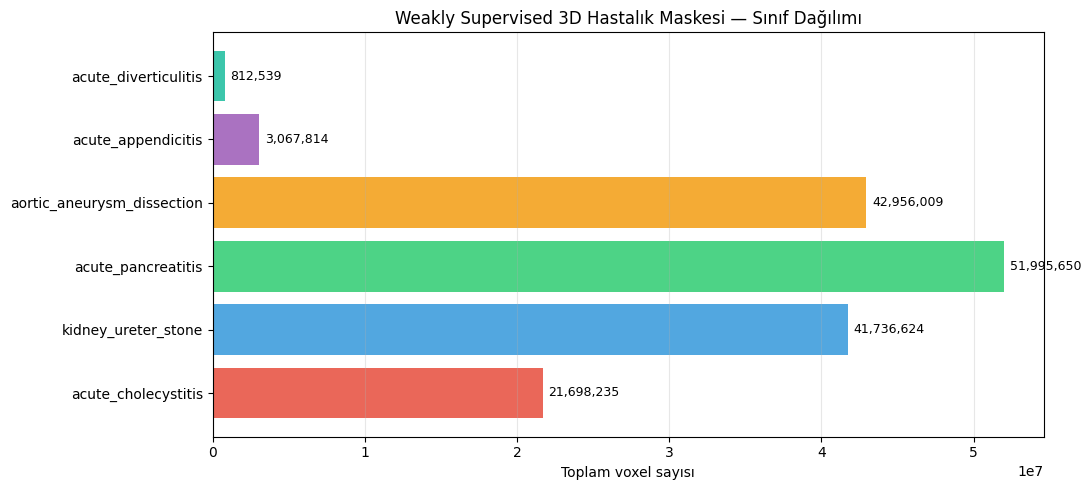

In [9]:
%matplotlib inline
import json
import matplotlib.pyplot as plt

stats_path = OUT_DIR / 'stats.json'
assert stats_path.exists(), f'stats.json bulunamadi: {stats_path}'

with open(stats_path) as f:
    stats = json.load(f)

classes = list(stats['voxel_counts'].keys())
counts  = list(stats['voxel_counts'].values())

print(f'İşlenen vaka: {stats["processed_cases"]}')
print()
for cls, n in zip(classes, counts):
    bar = '█' * min(40, int(n / max(counts) * 40)) if max(counts) else ''
    print(f'  {cls:35s}: {n:>12,}  {bar}')

fig, ax = plt.subplots(figsize=(11, 5))
colors = ['#e74c3c','#3498db','#2ecc71','#f39c12','#9b59b6','#1abc9c']
bars = ax.barh(classes, counts, color=colors, alpha=0.85)
ax.bar_label(bars, labels=[f'{n:,}' for n in counts], padding=4, fontsize=9)
ax.set_xlabel('Toplam voxel sayısı')
ax.set_title('Weakly Supervised 3D Hastalık Maskesi — Sınıf Dağılımı')
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

## [6] CT + Maske Görselleştirme

In [10]:
# Hangi vakayı görselleştirmek istiyorsunuz?
VIZ_CASE_ID = None   # None = ilk mevcut maske, ya da örn: 20001

/Users/ramazanpolat/Desktop/datasets/abdomen/.venv/lib/python3.9/site-packages/pydicom/pixel_data_handlers/numpy_handler.py:250: UserWarning: The length of the pixel data in the dataset (1048576 bytes) indicates it contains excess padding. 524288 bytes will be removed from the end of the data
  warnings.warn(msg)


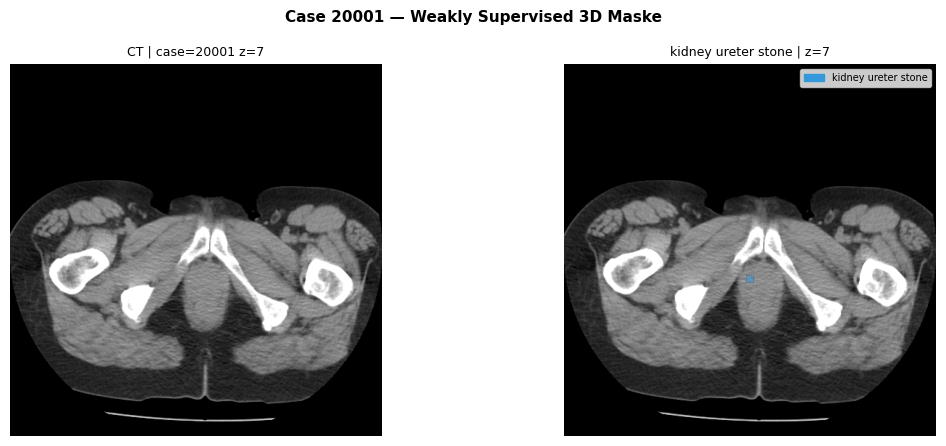

In [12]:
%matplotlib inline
import SimpleITK as sitk
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.colors as mcolors
from src.config import SUPER_CLASSES, RAW_TRAIN_DIR, RAW_TEST_DIR
from src.dicom_utils import load_series, window_hu, Window

COLORS   = [None,'#e74c3c','#3498db','#2ecc71','#f39c12','#9b59b6','#1abc9c']
SOFT_WIN = Window('soft_tissue', level=40, width=400)

masks = sorted(OUT_DIR.glob('*_disease.nii.gz'))
if not masks:
    print('Maske bulunamadi — önce [4] hücresini çalıştırın.')
else:
    if VIZ_CASE_ID:
        mask_path = OUT_DIR / f'ABE_{VIZ_CASE_ID:05d}_disease.nii.gz'
    else:
        mask_path = masks[0]

    cid = int(mask_path.stem.split('_')[1])
    case_dir = next((b/str(cid) for b in (RAW_TRAIN_DIR, RAW_TEST_DIR)
                     if (b/str(cid)).is_dir()), None)

    arr    = sitk.GetArrayFromImage(sitk.ReadImage(str(mask_path)))
    series = load_series(case_dir)

    # Hastalık içeren kesitlerden birini seç
    dis_zs = np.where(arr.max(axis=(1,2)) > 0)[0]
    if len(dis_zs) == 0:
        print('Bu vakada maske içeriği yok.')
    else:
        # Her sınıf için orta kesiti göster
        cls_in_mask = [c for c in range(1,7) if (arr==c).any()]
        fig, axes = plt.subplots(len(cls_in_mask), 2,
                                 figsize=(12, 4.5*len(cls_in_mask)))
        if len(cls_in_mask) == 1:
            axes = axes[np.newaxis,:]

        for ri, cid_cls in enumerate(cls_in_mask):
            cls_zs = np.where(arr.max(axis=(1,2)) == cid_cls)[0]
            z = cls_zs[len(cls_zs)//2]
            ct  = window_hu(series.hu[z], SOFT_WIN)
            msk = arr[z]

            ax = axes[ri,0]
            ax.imshow(ct, cmap='gray')
            ax.set_title(f'CT | case={cid} z={z}', fontsize=9)
            ax.axis('off')

            ax = axes[ri,1]
            ax.imshow(ct, cmap='gray')
            ov = np.zeros((*ct.shape,4), dtype=np.float32)
            patches = []
            for c2, clr in enumerate(COLORS[1:],1):
                reg = msk==c2
                if not reg.any(): continue
                rgba = mcolors.to_rgba(clr)
                ov[reg] = (*rgba[:3], 0.55)
                patches.append(mpatches.Patch(color=clr,
                    label=SUPER_CLASSES[c2-1].replace('_',' ')))
            ax.imshow(ov)
            if patches: ax.legend(handles=patches, loc='upper right', fontsize=7)
            ax.set_title(f'{SUPER_CLASSES[cid_cls-1].replace("_"," ")} | z={z}', fontsize=9)
            ax.axis('off')

        plt.suptitle(f'Case {cid} — Weakly Supervised 3D Maske', fontsize=11, fontweight='bold')
        plt.tight_layout()
        plt.show()

## [7] Analiz: BB Coverage & Z-Range Uyumu

In [13]:
import pandas as pd
from src.config import RAW_PATHOLOGY_TO_SUPER, SUPER_CLASSES

sheets  = pd.read_excel(BASE / 'Bilgi.xlsx', sheet_name=None)
all_ann = pd.concat([
    sheets['TRAIININGDATA'].assign(source='train'),
    sheets['COMPETITIONDATA'].assign(source='comp'),
], ignore_index=True)

def parse_bb(raw):
    try:
        a,b = raw.split('-')
        x1,y1 = map(int,a.split(','))
        x2,y2 = map(int,b.split(','))
        return (x1,y1,x2,y2) if x2>x1 and y2>y1 else None
    except: return None

records = []
for mask_path in sorted(OUT_DIR.glob('*_disease.nii.gz')):
    cid = int(mask_path.stem.split('_')[1])
    case_dir_ = next((b/str(cid) for b in (RAW_TRAIN_DIR,RAW_TEST_DIR)
                      if (b/str(cid)).is_dir()), None)
    if not case_dir_: continue
    try:
        ser_  = load_series(case_dir_)
        arr_  = sitk.GetArrayFromImage(sitk.ReadImage(str(mask_path)))
        idx_  = {img_id:i for i,img_id in enumerate(ser_.image_ids)}
        rows_ = all_ann[(all_ann['Case Number']==cid) &
                        (all_ann['Type']=='Bounding Box')]
        for _,r in rows_.iterrows():
            bb  = parse_bb(str(r['Data']))
            sid = RAW_PATHOLOGY_TO_SUPER.get(r['Class'])
            if bb is None or sid is None: continue
            z   = idx_.get(int(r['Image Id']))
            if z is None: continue
            gt   = np.zeros(arr_[z].shape,np.uint8); gt[bb[1]:bb[3],bb[0]:bb[2]]=1
            pred = (arr_[z]==sid+1).astype(np.uint8)
            tp   = (gt&pred).sum()
            records.append({
                'case'    : cid,
                'class'   : SUPER_CLASSES[sid].replace('_',' '),
                'BB_px'   : int(gt.sum()),
                'Mask_px' : int(pred.sum()),
                'TP_px'   : int(tp),
                'BB_Cov%' : round(tp/gt.sum()*100,1) if gt.sum() else 0.0,
                'MaskPr%' : round(tp/pred.sum()*100,1) if pred.sum() else 0.0,
            })
    except Exception as e:
        print(f'  [skip] {cid}: {e}')

if records:
    df_m = pd.DataFrame(records)
    print('Sınıf bazında ortalama metrikler:')
    print(df_m.groupby('class')[['BB_Cov%','MaskPr%']].mean().round(1).to_string())
    print(f'\nGenel BB Coverage  : {df_m["BB_Cov%"].mean():.1f}%')
    print(f'Genel Mask Precision: {df_m["MaskPr%"].mean():.1f}%')
    display(df_m)
else:
    print('Metrik hesaplanamadi.')

/Users/ramazanpolat/Desktop/datasets/abdomen/.venv/lib/python3.9/site-packages/pydicom/pixel_data_handlers/numpy_handler.py:250: UserWarning: The length of the pixel data in the dataset (1048576 bytes) indicates it contains excess padding. 524288 bytes will be removed from the end of the data
  warnings.warn(msg)
/Users/ramazanpolat/Desktop/datasets/abdomen/.venv/lib/python3.9/site-packages/pydicom/pixel_data_handlers/numpy_handler.py:250: UserWarning: The length of the pixel data in the dataset (525312 bytes) indicates it contains excess padding. 1024 bytes will be removed from the end of the data
  warnings.warn(msg)
/Users/ramazanpolat/Desktop/datasets/abdomen/.venv/lib/python3.9/site-packages/pydicom/pixel_data_handlers/numpy_handler.py:250: UserWarning: The length of the pixel data in the dataset (525312 bytes) indicates it contains excess padding. 1024 bytes will be removed from the end of the data
  warnings.warn(msg)
/Users/ramazanpolat/Desktop/datasets/abdomen/.venv/lib/python

Sınıf bazında ortalama metrikler:
                            BB_Cov%  MaskPr%
class                                       
acute appendicitis             89.8     90.9
acute cholecystitis            91.4     92.4
acute diverticulitis           74.7     96.5
acute pancreatitis             94.8     94.4
aortic aneurysm dissection     55.6     99.9
kidney ureter stone            95.5     89.8

Genel BB Coverage  : 78.4%
Genel Mask Precision: 95.8%


,case,class,BB_px,Mask_px,TP_px,BB_Cov%,MaskPr%
0,20001,kidney ureter stone,132,132,132,100.0,100.0
1,20001,kidney ureter stone,100,100,100,100.0,100.0
2,20002,kidney ureter stone,48,48,48,100.0,100.0
3,20002,kidney ureter stone,63,63,63,100.0,100.0
4,20003,acute appendicitis,156,156,156,100.0,100.0
...,...,...,...,...,...,...,...
24689,20734,kidney ureter stone,288,288,288,100.0,100.0
24690,20734,kidney ureter stone,196,196,196,100.0,100.0
24691,20734,kidney ureter stone,196,196,196,100.0,100.0
24692,20734,kidney ureter stone,270,270,270,100.0,100.0


## [8] Gerçek 3D Görselleştirme (Plotly Interactive)

Mevcut [6] bölümündeki 2D kesit görünümünün aksine bu bölüm:
- **marching cubes** ile her hastalık sınıfının 3D yüzeyini çıkarır
- **Plotly Mesh3d** ile notebook içinde döndürülebilir, zoomlanabilir 3D render yapar
- 3 adet aksiyel CT kesiti şeffaf arka plan düzlemi olarak ekler

`pip install plotly` gereklidir (bir kez).

In [ ]:
!pip install -q plotly

import numpy as np
import SimpleITK as sitk
import plotly.graph_objects as go
from skimage.measure import marching_cubes
from src.config import SUPER_CLASSES, RAW_TRAIN_DIR, RAW_TEST_DIR
from src.dicom_utils import load_series, window_hu, Window

# ─── Ayarlar ──────────────────────────────────────────────────────────────
VIZ_CASE_3D = None   # None=ilk mevcut maske, ya da örn: 20001
DOWNSAMPLE  = 2      # 1=tam, 2=yarı (hız/bellek dengesi)
SOFT_WIN    = Window("soft_tissue", level=40, width=400)

COLORS_HEX = [
    "#e74c3c",  # acute_cholecystitis
    "#3498db",  # kidney_ureter_stone
    "#2ecc71",  # acute_pancreatitis
    "#f39c12",  # aortic_aneurysm_dissection
    "#9b59b6",  # acute_appendicitis
    "#1abc9c",  # acute_diverticulitis
]

def _hex_to_rgb(h):
    h = h.lstrip("#")
    return tuple(int(h[i:i+2], 16) for i in (0, 2, 4))

# ─── Maske yükle ──────────────────────────────────────────────────────────
masks_3d = sorted(OUT_DIR.glob("*_disease.nii.gz"))
assert masks_3d, "Maske bulunamadi -- once [4] hucresini calistirin."

mask_path = (OUT_DIR / f"ABE_{VIZ_CASE_3D:05d}_disease.nii.gz"
             if VIZ_CASE_3D else masks_3d[0])
cid = int(mask_path.stem.split("_")[1])
print(f"Vaka: {cid}  |  {mask_path.name}")

sitk_mask = sitk.ReadImage(str(mask_path))
arr       = sitk.GetArrayFromImage(sitk_mask)   # (Z, Y, X)
spacing   = sitk_mask.GetSpacing()               # (sx, sy, sz) mm
print(f"Shape: {arr.shape}, spacing: {tuple(round(s,2) for s in spacing)} mm")

d      = DOWNSAMPLE
arr_ds = arr[::d, ::d, ::d]
sp_ds  = (spacing[0]*d, spacing[1]*d, spacing[2]*d)

# ─── CT serisi ────────────────────────────────────────────────────────────
case_dir = next((b/str(cid) for b in (RAW_TRAIN_DIR, RAW_TEST_DIR)
                 if (b/str(cid)).is_dir()), None)
series   = load_series(case_dir) if case_dir else None

# ─── Plotly figure ────────────────────────────────────────────────────────
traces = []

# 1) Her hastalik sinifi icin marching cubes -> Mesh3d
for cls_id in range(1, 7):
    region = (arr_ds == cls_id).astype(np.uint8)
    if region.sum() < 8:
        continue
    verts, faces, _, _ = marching_cubes(region, level=0.5)
    vx = verts[:, 2] * sp_ds[0]
    vy = verts[:, 1] * sp_ds[1]
    vz = verts[:, 0] * sp_ds[2]
    r, g, b = _hex_to_rgb(COLORS_HEX[cls_id - 1])
    cls_name = SUPER_CLASSES[cls_id - 1].replace("_", " ")
    traces.append(go.Mesh3d(
        x=vx, y=vy, z=vz,
        i=faces[:, 0], j=faces[:, 1], k=faces[:, 2],
        color=f"rgb({r},{g},{b})",
        opacity=0.75,
        name=cls_name,
        showlegend=True,
        flatshading=False,
        lighting=dict(ambient=0.4, diffuse=0.8, specular=0.2, roughness=0.5),
    ))
    print(f"  {cls_name}: {len(verts):,} vertex, {len(faces):,} face")

# 2) Aksiyel CT kesitlerini seffaf duzlem olarak ekle
if series is not None:
    dis_zs = np.where(arr.max(axis=(1, 2)) > 0)[0]
    n = len(dis_zs)
    slice_zs = [dis_zs[n // 4], dis_zs[n // 2], dis_zs[3 * n // 4]]
    H, W = arr.shape[1], arr.shape[2]
    X2d, Y2d = np.meshgrid(np.arange(W) * spacing[0],
                           np.arange(H) * spacing[1])
    for z_idx in slice_zs:
        ct_w = window_hu(series.hu[z_idx], SOFT_WIN)
        traces.append(go.Surface(
            x=X2d, y=Y2d,
            z=np.full_like(X2d, z_idx * spacing[2]),
            surfacecolor=ct_w,
            colorscale="gray",
            showscale=False,
            opacity=0.30,
            showlegend=False,
        ))

# ─── Layout ───────────────────────────────────────────────────────────────
fig = go.Figure(data=traces)
fig.update_layout(
    title=f"Case {cid} — 3D Hastalık Maskesi  (döndür / zoom / çift tık = sıfırla)",
    scene=dict(
        xaxis_title="X (mm)",
        yaxis_title="Y (mm)",
        zaxis_title="Z (mm)",
        aspectmode="data",
        bgcolor="rgb(15,15,25)",
        xaxis=dict(backgroundcolor="rgb(15,15,25)", gridcolor="#333"),
        yaxis=dict(backgroundcolor="rgb(15,15,25)", gridcolor="#333"),
        zaxis=dict(backgroundcolor="rgb(15,15,25)", gridcolor="#333"),
    ),
    paper_bgcolor="rgb(25,25,35)",
    font_color="white",
    legend=dict(x=0.01, y=0.99, bgcolor="rgba(0,0,0,0.55)", font_size=11),
    width=950, height=720,
)
fig.show()
